# Verificación e instalación de librerías base

- numpy: cálculo numérico y arreglos multidimensionales.
- pandas: manipulación de datos tabulares.
- matplotlib: visualización de datos.
- opencv-python: procesamiento de imágenes por computadora.
- scikit-learn: algoritmos clásicos de aprendizaje automático.

In [4]:
import sys
from pathlib import Path

# Subir un nivel: de /notebooks a la raíz del proyecto
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import *

print("Entorno configurado correctamente.")
print(f"Raíz del proyecto : {project_root}")
print(f"Datos raw         : {DATA_RAW}")
print(f"Datos processed   : {DATA_PROCESSED}")

Entorno configurado correctamente.
Raíz del proyecto : C:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA
Datos raw         : C:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA\data\raw
Datos processed   : C:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA\data\processed


# Carga de dataset

In [5]:
# Buscar el CSV de Open-Meteo en processed/
archivos = list(DATA_PROCESSED.glob("dataset_unido_2*.csv"))

if not archivos:
    print("No se encontró el archivo en data/processed/")
    print("  Asegúrate de que el CSV esté en esa carpeta.")
else:
    archivo_csv = archivos[0]
    print(f"Archivo encontrado: {archivo_csv.name}")

    df_raw = pd.read_csv(archivo_csv)

    print(f"Filas cargadas : {len(df_raw):,}")
    print(f"Columnas       : {df_raw.columns.tolist()}")
    print()
    print("Primeras 5 filas:")
    print(df_raw.head())

Archivo encontrado: dataset_unido_2.csv
Filas cargadas : 318,984
Columnas       : ['time', 'temperature', 'humidity', 'rain', 'pressure', 'wind_speed']

Primeras 5 filas:
                  time  temperature  humidity  rain  pressure  wind_speed
0  1990-01-01 00:00:00         21.5        92   0.0    1008.3         6.2
1  1990-01-01 01:00:00         21.4        91   0.0    1008.0         7.1
2  1990-01-01 02:00:00         21.6        88   0.0    1007.5         7.2
3  1990-01-01 03:00:00         21.4        86   0.0    1006.9         7.4
4  1990-01-01 04:00:00         21.1        85   0.0    1006.8         7.4


## 3. Conversión de la columna de tiempo

Convertimos `time` a datetime y extraemos solo la fecha (sin hora)
para poder agrupar por día.

In [6]:
# Convertir a datetime
df_raw["time"] = pd.to_datetime(df_raw["time"])

# Extraer solo la fecha (sin hora)
df_raw["Fecha"] = df_raw["time"].dt.date

print("Tipo de time  :", df_raw["time"].dtype)
print("Rango completo:", df_raw["time"].min().date(), "->", df_raw["time"].max().date())
print()
print("Registros por día (debe ser 24):")
registros_por_dia = df_raw.groupby("Fecha").size()
print(registros_por_dia.value_counts().head())

Tipo de time  : datetime64[us]
Rango completo: 1990-01-01 -> 2026-05-22

Registros por día (debe ser 24):
24    13291
Name: count, dtype: int64


## 4. Filtrar rango 1990 – 2026

Usamos datos desde 1990 — los modelos meteorológicos históricos
son más confiables en este período y tenemos 36 años de historia,
suficiente para entrenar un modelo robusto.

In [8]:
fecha_inicio = pd.Timestamp("1990-01-01")
fecha_fin    = pd.Timestamp("2026-12-31")

mask = (df_raw["time"] >= fecha_inicio) & (df_raw["time"] <= fecha_fin)
df_filtrado = df_raw[mask].copy()

print(f"Registros antes de filtrar : {len(df_raw):,}")
print(f"Registros después de filtrar: {len(df_filtrado):,}")
print(f"Rango filtrado             : {df_filtrado['time'].min().date()} -> {df_filtrado['time'].max().date()}")
print(f"Días esperados             : {(df_filtrado['time'].max() - df_filtrado['time'].min()).days // 1 + 1:,}")

Registros antes de filtrar : 318,984
Registros después de filtrar: 318,984
Rango filtrado             : 1990-01-01 -> 2026-05-22
Días esperados             : 13,291


## 4. Agregación horaria → diaria

Convertimos las 24 lecturas de cada día en un solo registro diario
usando las agregaciones correctas para cada variable:

| Variable | Agregación | Por qué |
|---|---|---|
| temperature | máx, mín, promedio | captura el rango térmico completo |
| humidity | máx, mín, promedio | captura variación diaria de humedad |
| rain | suma | lluvia acumulada del día |
| pressure | promedio | presión atmosférica media del día |
| wind_speed | máximo | el viento más fuerte del día es el relevante |

In [9]:
df_diario = df_filtrado.groupby("Fecha").agg(
    Temp_Max    = ("temperature", "max"),
    Temp_Min    = ("temperature", "min"),
    Temp_Prom   = ("temperature", "mean"),
    Humedad_Max = ("humidity",    "max"),
    Humedad_Min = ("humidity",    "min"),
    Humedad_Prom= ("humidity",    "mean"),
    Lluvia      = ("rain",        "sum"),
    Presion     = ("pressure",    "mean"),
    Viento_Max  = ("wind_speed",  "max"),
).reset_index()

# Redondear a 2 decimales
cols_num = df_diario.columns.drop("Fecha")
df_diario[cols_num] = df_diario[cols_num].round(2)

# Convertir Fecha a datetime
df_diario["Fecha"] = pd.to_datetime(df_diario["Fecha"])

print("Agregación completada.")
print(f"Filas  : {len(df_diario):,} días")
print(f"Columnas: {df_diario.shape[1]}")
print()
print("Primeras 5 filas:")
df_diario.head()

Agregación completada.
Filas  : 13,291 días
Columnas: 10

Primeras 5 filas:


,Fecha,Temp_Max,Temp_Min,Temp_Prom,Humedad_Max,Humedad_Min,Humedad_Prom,Lluvia,Presion,Viento_Max
0,1990-01-01,29.5,20.3,24.44,92,55,75.21,0.9,1007.80,8.9
1,1990-01-02,29.9,21.3,24.87,91,49,72.88,0.2,1006.82,8.9
2,1990-01-03,30.3,20.6,25.14,84,47,66.83,0.3,1005.49,7.9
3,1990-01-04,29.9,21.7,25.04,89,53,73.04,1.5,1005.89,7.2
4,1990-01-05,30.2,21.4,25.08,89,54,76.46,5.6,1005.76,6.9


## 6. Verificación del dataset diario

In [11]:
print("RESUMEN DEL DATASET DIARIO")
print(f"Filas     : {len(df_diario):,}")
print(f"Columnas  : {df_diario.shape[1]}")
print(f"Inicio    : {df_diario['Fecha'].min().date()}")
print(f"Fin       : {df_diario['Fecha'].max().date()}")
print()

# Verificar dias faltantes
dias_esperados = (df_diario["Fecha"].max() - df_diario["Fecha"].min()).days + 1
dias_faltantes = dias_esperados - len(df_diario)
print(f"Días esperados  : {dias_esperados:,}")
print(f"Días en dataset : {len(df_diario):,}")
print(f"Días faltantes  : {dias_faltantes}")

if dias_faltantes == 0:
    print("Serie temporal completa, sin días faltantes.")
else:
    print("Hay días faltantes.")
print()

# Nulos
print("Valores nulos por columna:")
nulos = df_diario.isnull().sum()
pct   = (nulos / len(df_diario) * 100).round(2)
print(pd.DataFrame({"Nulos": nulos, "%": pct}))

RESUMEN DEL DATASET DIARIO
Filas     : 13,291
Columnas  : 10
Inicio    : 1990-01-01
Fin       : 2026-05-22

Días esperados  : 13,291
Días en dataset : 13,291
Días faltantes  : 0
Serie temporal completa, sin días faltantes.

Valores nulos por columna:
              Nulos    %
Fecha             0  0.0
Temp_Max          0  0.0
Temp_Min          0  0.0
Temp_Prom         0  0.0
Humedad_Max       0  0.0
Humedad_Min       0  0.0
Humedad_Prom      0  0.0
Lluvia            0  0.0
Presion           0  0.0
Viento_Max        0  0.0


In [12]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
df_diario.describe().round(2)

Estadísticas descriptivas:


,Fecha,Temp_Max,Temp_Min,Temp_Prom,Humedad_Max,Humedad_Min,Humedad_Prom,Lluvia,Presion,Viento_Max
count,13291,13291.00,13291.00,13291.00,13291.00,13291.00,13291.00,13291.00,13291.00,13291.00
mean,2008-03-12 00:00:00,29.74,22.22,25.32,92.97,63.45,81.90,10.73,1005.59,8.78
min,1990-01-01 00:00:00,22.50,18.40,21.66,54.00,20.00,37.38,0.00,999.30,3.40
25%,1999-02-05 12:00:00,28.00,21.50,24.30,91.00,50.00,74.15,1.40,1004.81,7.00
50%,2008-03-12 00:00:00,29.30,22.20,25.03,97.00,69.00,87.50,7.20,1005.65,8.30
75%,2017-04-16 12:00:00,31.50,22.80,26.28,99.00,75.00,91.33,15.00,1006.45,10.00
max,2026-05-22 00:00:00,38.10,26.20,30.22,100.00,99.00,99.62,200.00,1010.05,32.70
std,NaN,2.44,1.02,1.41,9.50,16.09,12.82,14.14,1.25,2.67


## 7. Gráfica de verificación

Visualizamos la serie completa para confirmar que los datos
son coherentes y no hay anomalías visibles.

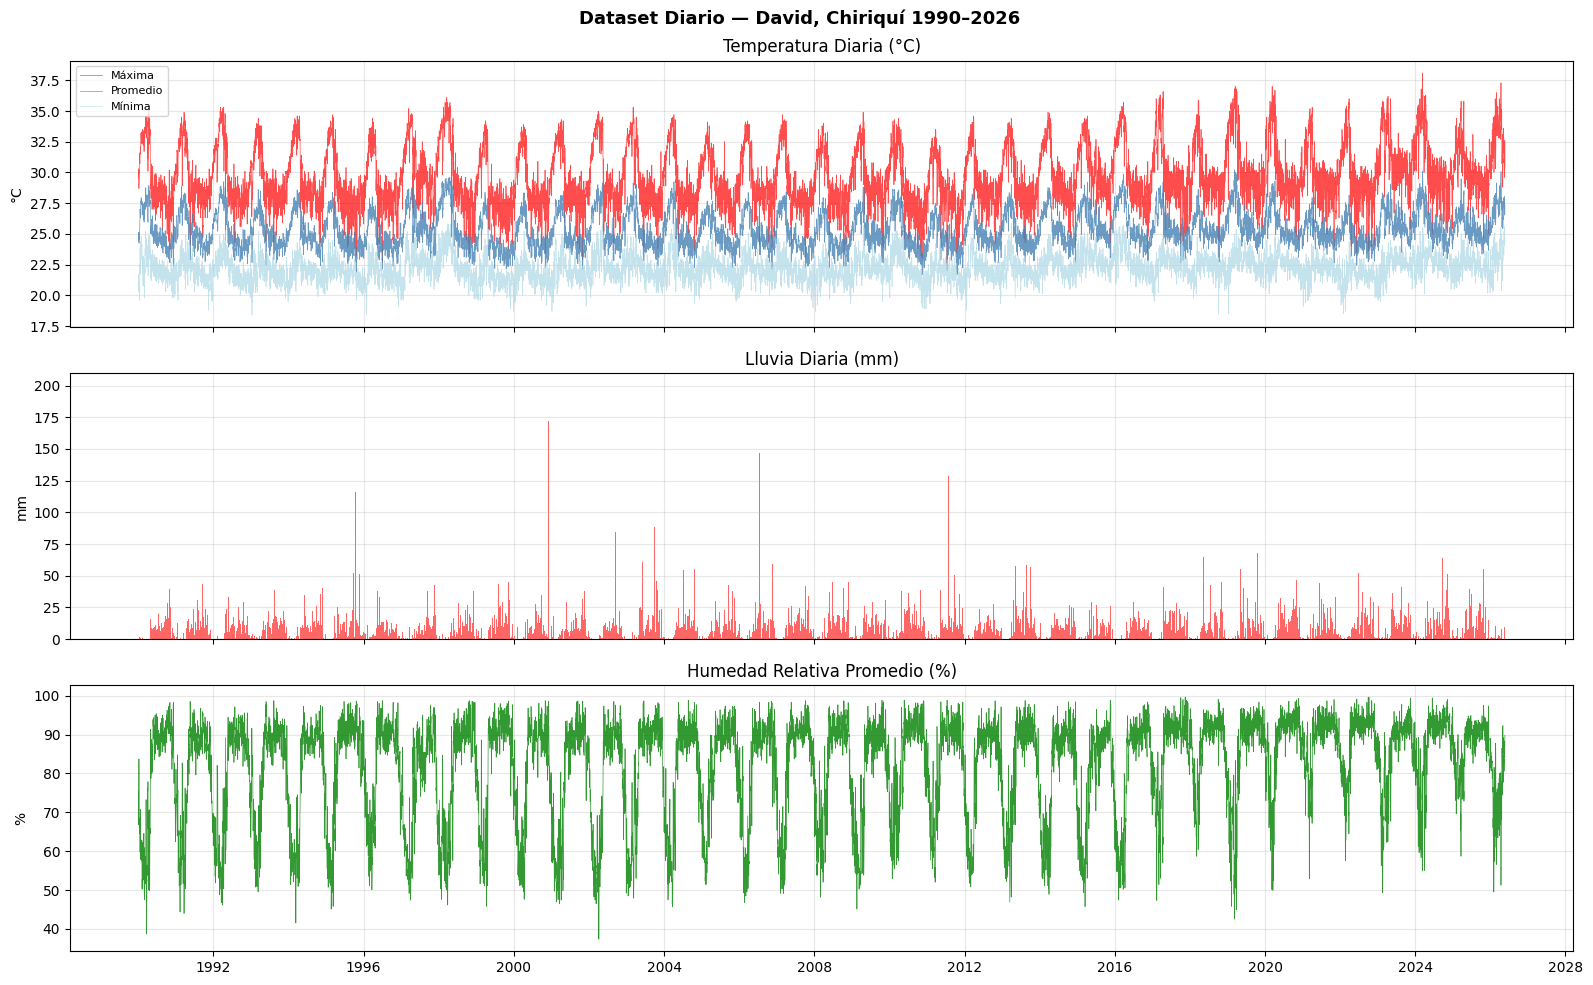

Gráfica guardada en reports/


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Temperatura
axes[0].plot(df_diario["Fecha"], df_diario["Temp_Max"],
             color="red", linewidth=0.5, alpha=0.7, label="Máxima")
axes[0].plot(df_diario["Fecha"], df_diario["Temp_Prom"],
             color="steelblue", linewidth=0.5, alpha=0.8, label="Promedio")
axes[0].plot(df_diario["Fecha"], df_diario["Temp_Min"],
             color="lightblue", linewidth=0.5, alpha=0.7, label="Mínima")
axes[0].set_title("Temperatura Diaria (°C)")
axes[0].set_ylabel("°C")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.3)

# Lluvia
axes[1].bar(df_diario["Fecha"], df_diario["Lluvia"],
            color="red", alpha=0.6, width=1)
axes[1].set_title("Lluvia Diaria (mm)")
axes[1].set_ylabel("mm")
axes[1].grid(alpha=0.3)

# Humedad
axes[2].plot(df_diario["Fecha"], df_diario["Humedad_Prom"],
             color="green", linewidth=0.5, alpha=0.8)
axes[2].set_title("Humedad Relativa Promedio (%)")
axes[2].set_ylabel("%")
axes[2].grid(alpha=0.3)

plt.suptitle("Dataset Diario — David, Chiriquí 1990–2026",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "verificacion_carga_datos.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 8. Temperatura promedio por década

Verificamos si hay una tendencia de calentamiento a lo largo de los años 

Temperatura y lluvia por década:
        Temp_Max_Prom  Temp_Prom_Prom  Lluvia_Total
Decada                                             
1990            29.51           25.20       37596.7
2000            29.42           25.14       39316.6
2010            29.81           25.46       39181.2
2020            30.51           25.57       26484.6


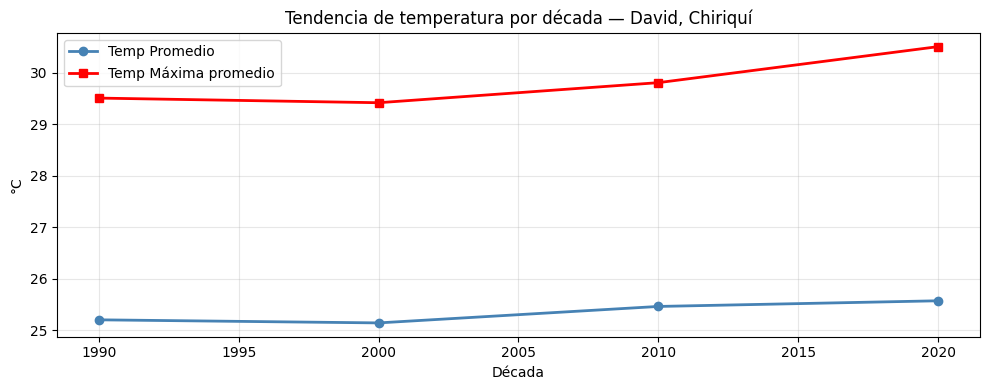

Gráfica guardada en reports/


In [14]:
df_diario["Año"]   = df_diario["Fecha"].dt.year
df_diario["Decada"]= (df_diario["Año"] // 10) * 10

resumen_decada = df_diario.groupby("Decada").agg(
    Temp_Max_Prom  = ("Temp_Max",  "mean"),
    Temp_Prom_Prom = ("Temp_Prom", "mean"),
    Lluvia_Total   = ("Lluvia",    "sum"),
).round(2)

print("Temperatura y lluvia por década:")
print(resumen_decada)

# Grafica de tendencia
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(resumen_decada.index, resumen_decada["Temp_Prom_Prom"],
        marker="o", color="steelblue", linewidth=2, label="Temp Promedio")
ax.plot(resumen_decada.index, resumen_decada["Temp_Max_Prom"],
        marker="s", color="red", linewidth=2, label="Temp Máxima promedio")
ax.set_title("Tendencia de temperatura por década — David, Chiriquí")
ax.set_xlabel("Década")
ax.set_ylabel("°C")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "tendencia_decadas.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 9. Guardado del dataset diario

In [17]:
# Guardar en data/raw/ como punto de partida del pipeline
output_path = DATA_RAW / "david_1990_2026_raw.csv"

df_diario.to_csv(output_path, index=False)

print(f"Dataset diario guardado en:")
print(f"  {output_path}")
print()
print(f"Filas    : {len(df_diario):,} días")
print(f"Columnas : {df_diario.shape[1]}")
print()
print("Columnas guardadas:")
for col in df_diario.columns:
    print(f"  {col}")
print()
print("Carga y agregación completada.")

Dataset diario guardado en:
  C:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA\data\raw\david_1990_2026_raw.csv

Filas    : 13,291 días
Columnas : 12

Columnas guardadas:
  Fecha
  Temp_Max
  Temp_Min
  Temp_Prom
  Humedad_Max
  Humedad_Min
  Humedad_Prom
  Lluvia
  Presion
  Viento_Max
  Año
  Decada

Carga y agregación completada.
